In [ ]:
import marimo as mo

# New and Repeat Customers

Using the customer_orders table, create a table showing new and repeat customer for every single date.

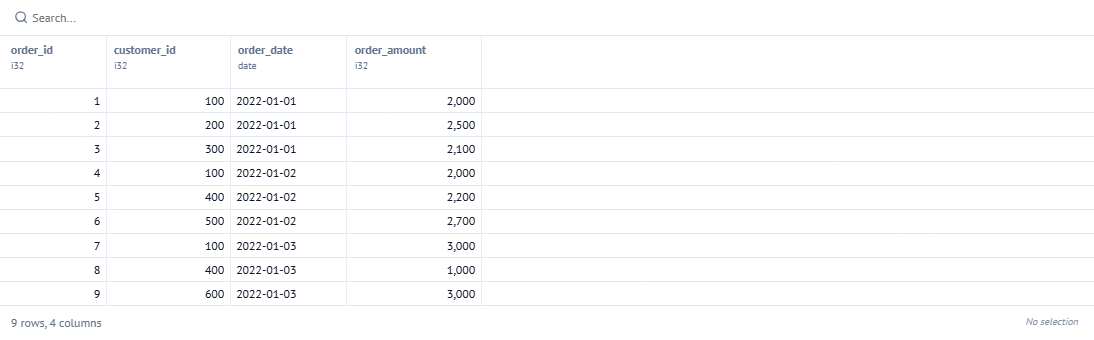

In [ ]:
_df = mo.sql(
    f"""
    DROP TABLE IF EXISTS customer_orders;

    CREATE TABLE customer_orders (
    	order_id INTEGER,
    	customer_id INTEGER,
    	order_date date,
    	order_amount INTEGER
    );

    INSERT INTO
    	customer_orders
    VALUES
    	(1, 100, CAST('2022-01-01' AS date), 2000),
    	(2, 200, CAST('2022-01-01' AS date), 2500),
    	(3, 300, CAST('2022-01-01' AS date), 2100),
    	(4, 100, CAST('2022-01-02' AS date), 2000),
    	(5, 400, CAST('2022-01-02' AS date), 2200),
    	(6, 500, CAST('2022-01-02' AS date), 2700),
    	(7, 100, CAST('2022-01-03' AS date), 3000),
    	(8, 400, CAST('2022-01-03' AS date), 1000),
    	(9, 600, CAST('2022-01-03' AS date), 3000);

    SELECT * FROM customer_orders;
    """
)

# Solution

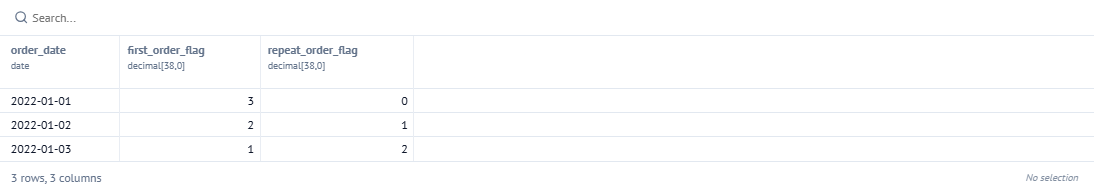

In [ ]:
_df = mo.sql(
    f"""
    WITH
    	new_customers AS (
    		SELECT
    			customer_id,
    			MIN(order_date) AS first_order_date
    		FROM
    			customer_orders
    		GROUP BY
    			customer_id
    	)
    SELECT
    	order_date,
    	SUM(
    		CASE
    			WHEN order_date = first_order_date THEN 1
    			ELSE 0
    		END
    	) AS first_order_flag,
    	SUM(
    		CASE
    			WHEN order_date != first_order_date THEN 1
    			ELSE 0
    		END
    	) AS repeat_order_flag
    FROM
    	customer_orders AS co
    	LEFT JOIN new_customers AS nc USING (customer_id)
    GROUP BY
    	order_date
    order by 1;
    """
)